# IF25-40305: Sistem Teknologi Multimedia (STM)
## Modul 04 — Loudness & Normalization: Peak, RMS, LUFS & Dynamic Level Control

**Institut Teknologi Sumatera (ITERA) — Program Studi Informatika**  
*Materi Kuliah & Hands-on Lab Semester Ganjil 2026/2027*

---

### 🎯 Capaian Pembelajaran Modul 04:
1. Membedakan metrik kenyaringan audio secara matematis dan perseptual: **Sample Peak (dBFS)**, **True Peak (dBTP)**, **RMS**, dan **LUFS/LKFS (ITU-R BS.1770)**.
2. Memahami peran **Crest Factor** dalam menjelaskan mengapa dua audio dengan amplitudo puncak yang sama dapat terdengar sangat timpang kenyaringannya.
3. Mengukur kenyaringan terintegrasi (*Integrated Loudness*) dan *Short-Term Loudness* menggunakan pustaka `pyloudnorm`.
4. Menerapkan **Peak Normalization** vs **Loudness Normalization** serta mengidentifikasi jebakan *digital clipping* ketika audio berdinamika tinggi didongkrak ke target platform streaming (mis. Spotify −14 LUFS).
5. Merancang skrip otomasi **Batch Normalization** ke berbagai profil target distribusi media digital.
6. Mengimplementasikan kurva amplop penguatan halus: **Fade In/Out** dan **Equal-Power Crossfade** berbasis identitas trigonometri NumPy.

## 1. Import Library & Persiapan Lingkungan

Modul ini memanfaatkan ekosistem pengolahan audio saintifik Python standar (`numpy`, `scipy`, `matplotlib`, `librosa`, `soundfile`) ditambah pustaka **`pyloudnorm`** untuk kalkulasi kenyaringan standar internasional ITU-R BS.1770-4.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import librosa
import soundfile as sf
import pyloudnorm as pyln
import IPython.display as ipd
from IPython.display import display

# Konfigurasi visualisasi konsisten
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120

# Palet warna resmi modul
C_SIGNAL   = '#0284c7'   # biru   — sinyal utama
C_ALT      = '#0ea5e9'   # langit — sinyal sekunder
C_NEUTRAL  = '#334155'   # slate  — teks / waveform mentah
C_ALERT    = '#dc2626'   # merah  — peak, clipping, bahaya
C_GOOD     = '#059669'   # hijau  — aman / target
C_ACCENT   = '#7c3aed'   # violet — LUFS / kurva khusus
C_GOLD     = '#c5a059'   # emas   — RMS / platform

# Batasan durasi pemutar audio agar notebook tetap ringan
PREVIEW_S = 4.0

def putar(sig, sr, label, normalize=False):
    """Menampilkan pemutar audio untuk cuplikan sinyal.
    Parameter normalize=False penting agar browser tidak mengubah-ubah volume asli!"""
    print(label)
    display(ipd.Audio(sig[:int(PREVIEW_S * sr)], rate=sr, normalize=normalize))

print(f"numpy      : {np.__version__}")
print(f"scipy      : {signal.__name__}")
print(f"librosa    : {librosa.__version__}")
print(f"soundfile  : {sf.__version__}")
print("pyloudnorm : (loaded)")
print("\n✅ Seluruh pustaka analisis kenyaringan audio berhasil dimuat!")

numpy      : 2.5.3
scipy      : scipy.signal
librosa    : 1.0.0
soundfile  : 0.14.0
pyloudnorm : (loaded)

✅ Seluruh pustaka analisis kenyaringan audio berhasil dimuat!


## 2. Memuat Ragam Berkas Audio

Untuk memahami perilaku berbagai metrik kenyaringan, kita memuat 4 berkas audio dengan profil dinamika yang sangat kontras:
1. **Drums (`drums_sample.wav`)**: Pukulan transien perkusi tajam, energi puncak tinggi tetapi cepat meluruh (rentang dinamika sesaat sangat tinggi).
2. **Klasik (`classical_sample.wav`)**: Dinamika orkestra gesek Brahms yang lebar (bagian hening sangat halus, bagian *tutti* meledak).
3. **Podcast (`podcast_sample.wav`)**: Artikulasi vokal manusia alami dengan jeda hening antarkata.
4. **Rekaman Kelas (`audio_dikelas.wav`)**: Rekaman kuliah asli di ruang GK2 ITERA dengan derau (*ambient noise*) AC dan kipas.

In [2]:
# Pencarian berkas audio defensif
def find_audio(filename):
    possible_paths = [
        f"audio/{filename}",
        f"notebook_handson/audio/{filename}",
        f"../audio/{filename}",
    ]
    return next((p for p in possible_paths if os.path.exists(p)), None)

SR = 22050  # Laju sampel acuan standar untuk analisis

daftar_audio = {
    'drums': 'drums_sample.wav',
    'classical': 'classical_sample.wav',
    'podcast': 'podcast_sample.wav',
    'kelas': 'audio_dikelas.wav'
}

data_audio = {}
for kunci, nama_berkas in daftar_audio.items():
    path = find_audio(nama_berkas)
    if path is None:
        raise FileNotFoundError(f"Berkas {nama_berkas} tidak ditemukan!")
    y, sr = librosa.load(path, sr=SR, mono=True)
    data_audio[kunci] = {
        'nama': nama_berkas,
        'path': path,
        'y': y,
        'sr': sr,
        'durasi': len(y) / sr
    }
    print(f"[{kunci:10s}] -> {nama_berkas:<22s} | Durasi: {len(y)/sr:5.2f} s | Sampel: {len(y):d}")

putar(data_audio['drums']['y'], SR, "\n🥁 Sampel Drums (Transien Tajam):")
putar(data_audio['classical']['y'], SR, "🎻 Sampel Musik Klasik (Dinamika Lebar):")
putar(data_audio['podcast']['y'], SR, "🎙️ Sampel Podcast Vokal (Dialog):")

[drums     ] -> drums_sample.wav       | Durasi:  8.00 s | Sampel: 176400
[classical ] -> classical_sample.wav   | Durasi: 10.00 s | Sampel: 220500
[podcast   ] -> podcast_sample.wav     | Durasi:  9.00 s | Sampel: 198450
[kelas     ] -> audio_dikelas.wav      | Durasi:  6.51 s | Sampel: 143443

🥁 Sampel Drums (Transien Tajam):


🎻 Sampel Musik Klasik (Dinamika Lebar):


🎙️ Sampel Podcast Vokal (Dialog):


## 3. Metrik Puncak: Sample Peak vs True Peak (Inter-Sample Peak)

### 🔍 Apa Perbedaan Sample Peak dan True Peak?
- **Sample Peak ($x_{\text{peak}}$)**: Nilai mutlak terbesar dari titik-titik sampel diskrit yang tersimpan:
  $$\text{Sample Peak (dBFS)} = 20 \log_{10} \left( \max_n |x[n]| \right)$$
  Metrik ini hanya membaca nilai tepat pada kisi pencuplikan $t = n \cdot T_s$.
- **True Peak (dBTP)**: Puncak analog kontinu yang sebenarnya terjadi setelah rekonstruksi filter interpolasi DAC (*Digital-to-Analog Converter*). Standar **ITU-R BS.1770** menghitung True Peak dengan melakukan **oversampling $4\times$** sebelum membaca puncak. Sinyal antartitik dapat melambung melebihi $0\text{ dBFS}$ meskipun seluruh titik diskritnya $<0\text{ dBFS}$!

In [3]:
def hitung_peaks(y, oversample=4):
    """Menghitung Sample Peak dan True Peak (via oversampling polifase)."""
    # 1. Sample peak
    sp_linear = np.max(np.abs(y))
    sp_dbfs = 20 * np.log10(sp_linear) if sp_linear > 0 else -100.0
    
    # 2. True peak dengan oversampling 4x menggunakan filter polifase Scipy
    y_oversampled = signal.resample_poly(y, up=oversample, down=1)
    tp_linear = np.max(np.abs(y_oversampled))
    tp_dbtp = 20 * np.log10(tp_linear) if tp_linear > 0 else -100.0
    
    return sp_linear, sp_dbfs, tp_linear, tp_dbtp, y_oversampled

print(f"{'Kategori':12s} | {'Sample Peak (dBFS)':20s} | {'True Peak (dBTP)':18s} | {'Beda Inter-Sample'}")
print("-" * 72)
for kunci, d in data_audio.items():
    sp_lin, sp_db, tp_lin, tp_db, _ = hitung_peaks(d['y'])
    d['sp_db'] = sp_db
    d['tp_db'] = tp_db
    selisih = tp_db - sp_db
    print(f"{kunci:12s} | {sp_db:18.2f} dBFS | {tp_db:16.2f} dBTP | +{selisih:5.2f} dB")

Kategori     | Sample Peak (dBFS)   | True Peak (dBTP)   | Beda Inter-Sample
------------------------------------------------------------------------
drums        |              -8.39 dBFS |            -8.38 dBTP | + 0.01 dB
classical    |              -4.56 dBFS |            -4.41 dBTP | + 0.15 dB
podcast      |              -5.51 dBFS |            -5.48 dBTP | + 0.02 dB
kelas        |              -1.06 dBFS |            -1.04 dBTP | + 0.02 dB


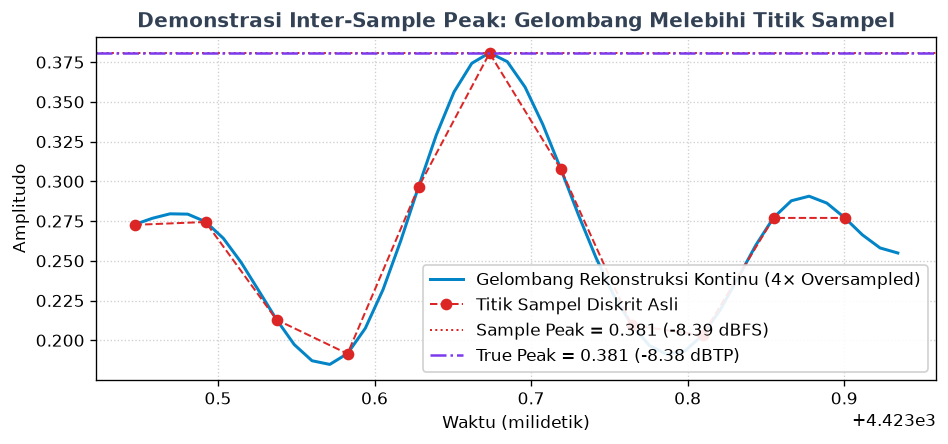

💡 Catatan Penting: True Peak melambung 0.01 dB di atas Sample Peak!
Jika audio dinormalisasi persis 0.0 dBFS, inter-sample peak akan menjebol batas analog DAC pengguna.


In [4]:
# Visualisasi Inter-sample Peak pada cuplikan transien drum
y_drum = data_audio['drums']['y']
sp_lin, sp_db, tp_lin, tp_db, y_4x = hitung_peaks(y_drum)

# Cari posisi puncak absolut
idx_max = np.argmax(np.abs(y_drum))
# Ambil jendela sempit 10 sampel di sekitar puncak
idx_start = max(0, idx_max - 5)
idx_end = min(len(y_drum), idx_max + 6)

t_orig = np.arange(idx_start, idx_end) / SR * 1000  # ms
s_orig = y_drum[idx_start:idx_end]

# Kisi oversampled 4x
idx_start_4x = idx_start * 4
idx_end_4x = idx_end * 4
t_4x = np.arange(idx_start_4x, idx_end_4x) / (SR * 4) * 1000
s_4x = y_4x[idx_start_4x:idx_end_4x]

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(t_4x, s_4x, color=C_SIGNAL, lw=1.8, label='Gelombang Rekonstruksi Kontinu (4× Oversampled)')
ax.plot(t_orig, s_orig, color=C_ALERT, marker='o', markersize=6, ls='--', lw=1.2, label='Titik Sampel Diskrit Asli')

ax.axhline(sp_lin, color=C_ALERT, ls=':', lw=1.2, label=f'Sample Peak = {sp_lin:.3f} ({sp_db:.2f} dBFS)')
ax.axhline(tp_lin, color=C_ACCENT, ls='-.', lw=1.5, label=f'True Peak = {tp_lin:.3f} ({tp_db:.2f} dBTP)')

ax.set_title("Demonstrasi Inter-Sample Peak: Gelombang Melebihi Titik Sampel", fontweight='bold', color=C_NEUTRAL)
ax.set_xlabel("Waktu (milidetik)")
ax.set_ylabel("Amplitudo")
ax.grid(True, ls=':', alpha=0.6)
ax.legend(loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.show()

print(f"💡 Catatan Penting: True Peak melambung {tp_db - sp_db:.2f} dB di atas Sample Peak!")
print("Jika audio dinormalisasi persis 0.0 dBFS, inter-sample peak akan menjebol batas analog DAC pengguna.")

## 4. Energi Kontinu: RMS & Crest Factor

### 📊 Mengapa Peak Saja Tidak Cukup?
- **Root Mean Square (RMS)** mengukur rata-rata kuadrat energi sinyal kontinu:
  $$x_{\text{RMS}} = \sqrt{\frac{1}{N} \sum_{n=0}^{N-1} x^2[n]}, \quad \text{RMS (dBFS)} = 20 \log_{10}(x_{\text{RMS}})$$
- **Crest Factor ($C$)**: Rasio antara puncak sesaat terhadap energi rata-rata:
  $$C = \frac{x_{\text{peak}}}{x_{\text{RMS}}}, \quad C_{\text{dB}} = \text{Peak (dBFS)} - \text{RMS (dBFS)}$$
  Crest factor yang tinggi menandakan sinyal sarat dengan ketukan transien tajam (seperti drum), sedangkan crest factor rendah menandakan sinyal padat terkompresi.

In [5]:
print(f"{'Kategori':12s} | {'Peak (dBFS)':12s} | {'RMS (dBFS)':12s} | {'Crest Factor (dB)':18s}")
print("-" * 62)
for kunci, d in data_audio.items():
    y = d['y']
    peak_linear = np.max(np.abs(y))
    rms_linear = np.sqrt(np.mean(y**2))
    
    peak_db = 20 * np.log10(peak_linear)
    rms_db = 20 * np.log10(rms_linear)
    crest_db = peak_db - rms_db
    
    d['rms_db'] = rms_db
    d['crest_db'] = crest_db
    print(f"{kunci:12s} | {peak_db:10.2f} dB | {rms_db:10.2f} dB | {crest_db:16.2f} dB")

Kategori     | Peak (dBFS)  | RMS (dBFS)   | Crest Factor (dB) 
--------------------------------------------------------------
drums        |      -8.39 dB |     -27.52 dB |            19.13 dB
classical    |      -4.56 dB |     -21.70 dB |            17.14 dB
podcast      |      -5.51 dB |     -20.63 dB |            15.12 dB
kelas        |      -1.06 dB |     -18.12 dB |            17.06 dB


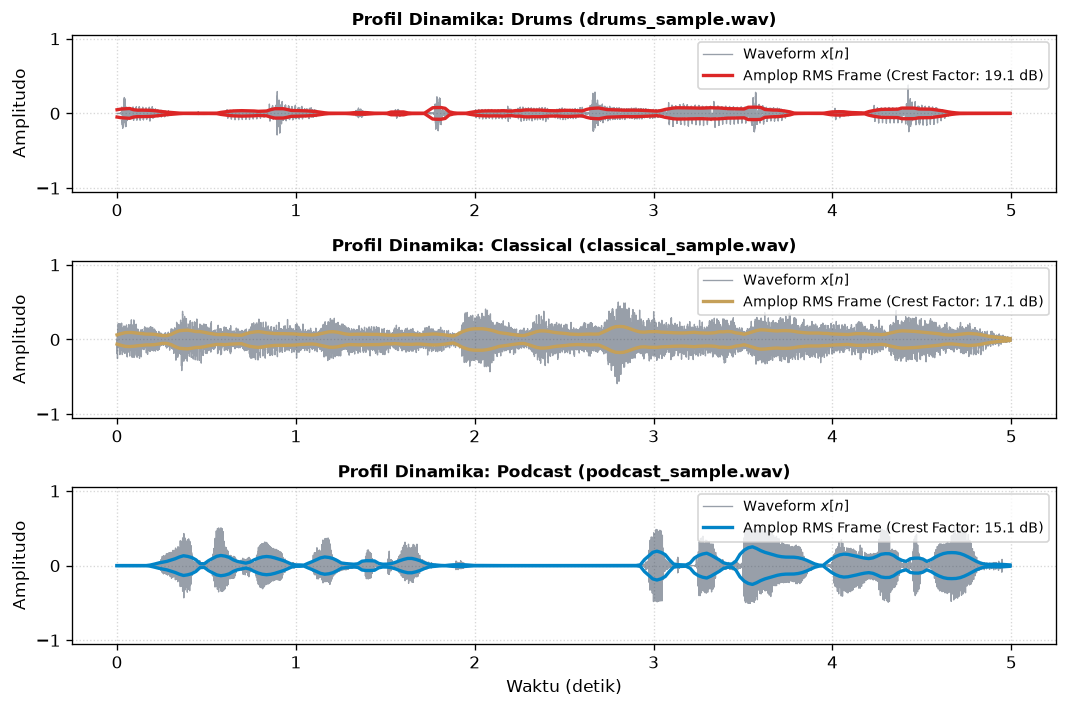

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=False)

contoh_kunci = ['drums', 'classical', 'podcast']
warna_list = [C_ALERT, C_GOLD, C_SIGNAL]

for ax, kunci, warna in zip(axes, contoh_kunci, warna_list):
    y = data_audio[kunci]['y'][:int(5.0 * SR)]
    t = np.arange(len(y)) / SR
    
    # Hitung RMS per frame (frame length = 2048 sampel, hop = 512 sampel)
    frame_len = 2048
    hop_len = 512
    rms_frames = librosa.feature.rms(y=y, frame_length=frame_len, hop_length=hop_len)[0]
    t_rms = librosa.frames_to_time(np.arange(len(rms_frames)), sr=SR, hop_length=hop_len)
    
    ax.plot(t, y, color=C_NEUTRAL, alpha=0.5, lw=0.8, label='Waveform $x[n]$')
    ax.plot(t_rms, rms_frames, color=warna, lw=2.0, label=f'Amplop RMS Frame (Crest Factor: {data_audio[kunci]["crest_db"]:.1f} dB)')
    ax.plot(t_rms, -rms_frames, color=warna, lw=2.0)
    
    ax.set_title(f"Profil Dinamika: {kunci.capitalize()} ({data_audio[kunci]['nama']})", fontweight='bold', fontsize=10)
    ax.set_ylabel("Amplitudo")
    ax.set_ylim(-1.05, 1.05)
    ax.grid(True, ls=':', alpha=0.5)
    ax.legend(loc='upper right', fontsize=8.5)

axes[-1].set_xlabel("Waktu (detik)")
plt.tight_layout()
plt.show()

## 5. Standar Modern: Pengukuran LUFS dengan `pyloudnorm`

### 🎧 Mengapa Standar LUFS Diciptakan?
Telinga manusia tidak merespons semua frekuensi secara seimbang (kurva *Equal-Loudness Fletcher-Munson*). Standar **ITU-R BS.1770 / EBU R128** merumuskan **LUFS (Loudness Units Full Scale)**:
1. **Filter K-Weighting**: Menaikkan frekuensi tinggi (+4 dB di atas 1,5 kHz simulasi resonansi kepala) dan memotong frekuensi rendah ($<100\text{ Hz}$).
2. **Gating Ganda**:
   - *Absolute gate* pada $-70\text{ LUFS}$ (mengabaikan keheningan total).
   - *Relative gate* pada $-10\text{ LU}$ di bawah kenyaringan tanpa jeda (mencegah jeda istirahat vokal menurunkan angka integrasi).

### 🎭 Demonstrasi: "Puncak Amplitudo Sama, Tetapi Kenyaringan Berbeda Jauh"
Mari kita buktikan secara empiris! Kita normalkan Drums, Klasik, dan Podcast ke puncak yang **persis sama: −1.0 dBFS**, lalu kita ukur kenyaringan perseptualnya (LUFS).

In [7]:
meter = pyln.Meter(SR)  # Inisialisasi pengukur kenyaringan ITU-R BS.1770

print(f"{'Kategori':12s} | {'Integrated LUFS Asli':22s}")
print("-" * 40)
for kunci, d in data_audio.items():
    lufs = meter.integrated_loudness(d['y'])
    d['lufs_asli'] = lufs
    print(f"{kunci:12s} | {lufs:18.2f} LUFS")

print("\n" + "=" * 65)
print("DEMONSTRASI: Seluruh audio dinormalisasi ke Sample Peak identik (-1.0 dBFS)")
print("=" * 65)

print(f"{'Kategori':12s} | {'Peak Normal':15s} | {'LUFS Terukur':16s} | {'Sensasi Telinga'}")
print("-" * 65)
for kunci in ['drums', 'classical', 'podcast']:
    y = data_audio[kunci]['y']
    # Normalisasi puncak ke -1.0 dBFS
    y_pnorm = pyln.normalize.peak(y, -1.0)
    lufs_pnorm = meter.integrated_loudness(y_pnorm)
    data_audio[kunci]['y_pnorm'] = y_pnorm
    data_audio[kunci]['lufs_pnorm'] = lufs_pnorm
    print(f"{kunci:12s} | {-1.0:12.2f} dBFS | {lufs_pnorm:13.2f} LUFS | Timpang {lufs_pnorm - (-14.0):+.1f} LU dari Spotify")

putar(data_audio['drums']['y_pnorm'], SR, "\n🥁 Drums pada -1 dBFS Peak (Terdengar pelan & sayup karena Crest Factor tinggi):")
putar(data_audio['podcast']['y_pnorm'], SR, "🎙️ Podcast pada -1 dBFS Peak (Terdengar jauh lebih keras di telinga!):")

Kategori     | Integrated LUFS Asli  
----------------------------------------
drums        |             -29.09 LUFS
classical    |             -21.78 LUFS
podcast      |             -20.36 LUFS
kelas        |             -19.79 LUFS

DEMONSTRASI: Seluruh audio dinormalisasi ke Sample Peak identik (-1.0 dBFS)
Kategori     | Peak Normal     | LUFS Terukur     | Sensasi Telinga
-----------------------------------------------------------------
drums        |        -1.00 dBFS |        -21.70 LUFS | Timpang -7.7 LU dari Spotify
classical    |        -1.00 dBFS |        -18.22 LUFS | Timpang -4.2 LU dari Spotify
podcast      |        -1.00 dBFS |        -15.86 LUFS | Timpang -1.9 LU dari Spotify

🥁 Drums pada -1 dBFS Peak (Terdengar pelan & sayup karena Crest Factor tinggi):


🎙️ Podcast pada -1 dBFS Peak (Terdengar jauh lebih keras di telinga!):


## 6. Komparasi Nyata: Peak Normalization vs Loudness Normalization

### ⚖️ Perbandingan Filosofis:
- **Peak Normalization**: Mencari sampel tertinggi, lalu mengalikan seluruh berkas dengan satu nilai $g = \frac{10^{P_{\text{target}}/20}}{\max |x[n]|}$. Puncak aman dari clipping, tetapi volume antarlagu tetap timpang.
- **Loudness Normalization**: Mengukur LUFS terintegrasi, lalu menyesuaikan gain sebesar $\Delta G = L_{\text{target}} - L_{\text{measured}}$. Kenyaringan seragam, tetapi **waspada:** jika materi memiliki puncak transien liar, penaikan gain dapat memicu **clipping ($>0\text{ dBFS}$)**!

In [8]:
TARGET_SPOTIFY = -14.0  # Standar kenyaringan Spotify (-14 LUFS)

print(f"{'Kategori':10s} | {'LUFS Asli':11s} | {'Gain Ditambah':14s} | {'Peak Baru':12s} | {'Status Batas 0 dBFS'}")
print("-" * 72)

for kunci in ['drums', 'classical', 'podcast', 'kelas']:
    d = data_audio[kunci]
    y = d['y']
    lufs_asli = d['lufs_asli']
    
    # Gain koreksi menuju -14 LUFS
    delta_gain_db = TARGET_SPOTIFY - lufs_asli
    # Normalisasi kenyaringan
    y_lnorm = pyln.normalize.loudness(y, lufs_asli, TARGET_SPOTIFY)
    d['y_lnorm'] = y_lnorm
    
    new_peak_lin = np.max(np.abs(y_lnorm))
    new_peak_db = 20 * np.log10(new_peak_lin)
    
    if new_peak_db > 0.0:
        status = f"🚨 CLIPPING! (+{new_peak_db:.2f} dBFS)"
    else:
        status = f"✅ Aman ({new_peak_db:.2f} dBFS)"
        
    print(f"{kunci:10s} | {lufs_asli:9.2f} | {delta_gain_db:+12.2f} dB | {new_peak_db:10.2f} dB | {status}")

print("\n💡 Pelajaran Fundamental:")
print("Drums dan Klasik mengalami CLIPPING parah saat dipaksa menyentuh -14 LUFS murni!")
print("Inilah alasan mengapa industri rekaman WAJIB menggunakan COMPRESSOR dan LIMITER (Modul 05).")

Kategori   | LUFS Asli   | Gain Ditambah  | Peak Baru    | Status Batas 0 dBFS
------------------------------------------------------------------------
drums      |    -29.09 |       +15.09 dB |       6.70 dB | 🚨 CLIPPING! (+6.70 dBFS)
classical  |    -21.78 |        +7.78 dB |       3.22 dB | 🚨 CLIPPING! (+3.22 dBFS)
podcast    |    -20.36 |        +6.36 dB |       0.86 dB | 🚨 CLIPPING! (+0.86 dBFS)
kelas      |    -19.79 |        +5.79 dB |       4.73 dB | 🚨 CLIPPING! (+4.73 dBFS)

💡 Pelajaran Fundamental:
Drums dan Klasik mengalami CLIPPING parah saat dipaksa menyentuh -14 LUFS murni!
Inilah alasan mengapa industri rekaman WAJIB menggunakan COMPRESSOR dan LIMITER (Modul 05).


/Users/martinmanullang/Developer/IF25-40305-handson/.venv/lib/python3.12/site-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")


## 7. Normalisasi Batch ke Target Platform Streaming

### 🌐 Standar Platform Distribusi Multimedia
| Platform / Standar | Integrated Target | Max True Peak | Catatan Rekayasa |
|---|---|---|---|
| **Spotify** | `−14.0 LUFS` | `−1.0 dBTP` | Format streaming OGG/AAC standar |
| **YouTube** | `−14.0 LUFS` | `−1.0 dBTP` | Hanya meredam video yang terlalu keras |
| **Apple Music** | `−16.0 LUFS` | `−1.0 dBTP` | Menggunakan algoritma Sound Check |
| **EBU R128 (TV)** | `−23.0 LUFS` | `−1.0 dBTP` | Standar broadcast televisi digital Eropa |
| **Netflix** | `−27.0 LUFS` | `−2.0 dBTP` | Fokus pada gating dialog vokal |

Berikut adalah fungsi otomatis untuk memproses banyak berkas sekaligus (*batch normalization*) dengan proteksi *safety scaling*.

In [9]:
def batch_normalize_audio(audio_dict, target_lufs=-14.0, max_peak_db=-1.0, output_dir="output_normalized"):
    """Menormalkan kumpulan berkas audio ke standar platform streaming."""
    os.makedirs(output_dir, exist_ok=True)
    meter = pyln.Meter(SR)
    hasil = {}
    
    print(f"🚀 Memulai Normalisasi Batch ke Target: {target_lufs:.1f} LUFS (Plafon: {max_peak_db:.1f} dBFS)...\n")
    
    for nama, item in audio_dict.items():
        y = item['y']
        sr = item['sr']
        
        # 1. Ukur LUFS awal
        loudness_in = meter.integrated_loudness(y)
        # 2. Normalisasi kenyaringan
        y_norm = pyln.normalize.loudness(y, loudness_in, target_lufs)
        
        # 3. Pemeriksaan plafon keamanan puncak
        peak_lin = np.max(np.abs(y_norm))
        peak_db = 20 * np.log10(peak_lin) if peak_lin > 0 else -100
        
        # Jika melebihi plafon aman, terapkan safety attenuation
        safety_applied = False
        if peak_db > max_peak_db:
            gain_safety = 10 ** ((max_peak_db - peak_db) / 20)
            y_norm = y_norm * gain_safety
            safety_applied = True
            
        loudness_final = meter.integrated_loudness(y_norm)
        peak_final_db = 20 * np.log10(np.max(np.abs(y_norm)))
        
        out_file = os.path.join(output_dir, f"{nama}_norm_{abs(int(target_lufs))}lufs.wav")
        sf.write(out_file, y_norm, sr, subtype='PCM_16')
        
        hasil[nama] = {
            'file': out_file,
            'lufs_awal': loudness_in,
            'lufs_akhir': loudness_final,
            'peak_akhir': peak_final_db,
            'safety_applied': safety_applied
        }
        status_safety = "⚠️ Safety Scaled" if safety_applied else "✅ Perfect Match"
        print(f"[{nama:10s}] -> LUFS: {loudness_final:6.2f} | Peak: {peak_final_db:6.2f} dBFS | {status_safety}")
        
    return hasil

hasil_spotify = batch_normalize_audio(data_audio, target_lufs=-14.0, max_peak_db=-1.0)

🚀 Memulai Normalisasi Batch ke Target: -14.0 LUFS (Plafon: -1.0 dBFS)...

[drums     ] -> LUFS: -21.70 | Peak:  -1.00 dBFS | ⚠️ Safety Scaled
[classical ] -> LUFS: -18.22 | Peak:  -1.00 dBFS | ⚠️ Safety Scaled
[podcast   ] -> LUFS: -15.86 | Peak:  -1.00 dBFS | ⚠️ Safety Scaled
[kelas     ] -> LUFS: -19.73 | Peak:  -1.00 dBFS | ⚠️ Safety Scaled


/Users/martinmanullang/Developer/IF25-40305-handson/.venv/lib/python3.12/site-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/Users/martinmanullang/Developer/IF25-40305-handson/.venv/lib/python3.12/site-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/Users/martinmanullang/Developer/IF25-40305-handson/.venv/lib/python3.12/site-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")
/Users/martinmanullang/Developer/IF25-40305-handson/.venv/lib/python3.12/site-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")


## 8. Desain Kontrol Gain & Transisi: Fade In/Out & Equal-Power Crossfade

### 🔇 Mengapa Pemotongan Audio Sering Menimbulkan Letupan 'Klik'?
Jika audio dipotong secara instan pada nilai bukan nol (*non-zero crossing*), terjadi lonjakan diskontinuitas mendadak. Turunan sinyal mendekati tak hingga ($\frac{dx}{dt} \to \infty$), memicu kebocoran energi frekuensi tinggi tajam (*click/pop artifact*).

### 🎚️ Solusi: Fade In/Out & Crossfade
1. **Fade In / Fade Out**: Mengalikan sinyal dengan amplop penaikan/penurunan bertahap.
2. **Crossfade Transisi Antarlagu**:
   - **Linear Crossfade**: $g_A = 1 - t$, $g_B = t$. Di titik tengah transisi, daya akustik total adalah $g_A^2 + g_B^2 = 0.5^2 + 0.5^2 = 0.5$ ($\mathbf{-3.01\text{ dB}}$)! Transisi terasa merosot/kendor volumenya.
   - **Equal-Power Crossfade**: Berbasis sinusoidal $g_A = \cos\left(\frac{\pi}{2} t\right)$ dan $g_B = \sin\left(\frac{\pi}{2} t\right)$. Karena $\cos^2\theta + \sin^2\theta = \mathbf{1.0}$, daya total akustik terjaga konstan $0\text{ dB}$ tanpa penurunan volume!

In [10]:
def terapkan_fade(y, sr, fade_in_s=0.5, fade_out_s=0.5, tipe='equal_power'):
    """Menerapkan fade in dan fade out pada berkas audio."""
    y_out = np.copy(y)
    n_in = int(fade_in_s * sr)
    n_out = int(fade_out_s * sr)
    
    if n_in > 0:
        t_in = np.linspace(0, 1, n_in)
        if tipe == 'linear':
            gain_in = t_in
        elif tipe == 'equal_power':
            gain_in = np.sin(np.pi / 2 * t_in)
        y_out[:n_in] *= gain_in
        
    if n_out > 0:
        t_out = np.linspace(0, 1, n_out)
        if tipe == 'linear':
            gain_out = 1 - t_out
        elif tipe == 'equal_power':
            gain_out = np.cos(np.pi / 2 * t_out)
        y_out[-n_out:] *= gain_out
        
    return y_out

def crossfade(y1, y2, sr, durasi_s=2.0, tipe='equal_power'):
    """Menyambung dua audio dengan teknik crossfade."""
    n_cross = int(durasi_s * sr)
    t = np.linspace(0, 1, n_cross)
    
    if tipe == 'linear':
        g1 = 1 - t
        g2 = t
    elif tipe == 'equal_power':
        g1 = np.cos(np.pi / 2 * t)
        g2 = np.sin(np.pi / 2 * t)
        
    # Bagian awal lagu 1 tanpa transisi
    head = y1[:-n_cross]
    # Bagian tumpang tindih
    overlap = y1[-n_cross:] * g1 + y2[:n_cross] * g2
    # Bagian ekor lagu 2 tanpa transisi
    tail = y2[n_cross:]
    
    return np.concatenate([head, overlap, tail])

# Uji coba crossfade: dari Drums ke Musik Klasik
y_drum_fade = terapkan_fade(data_audio['drums']['y'][:int(5.0 * SR)], SR, fade_in_s=0.5, fade_out_s=1.5)
y_class_fade = terapkan_fade(data_audio['classical']['y'][:int(5.0 * SR)], SR, fade_in_s=1.5, fade_out_s=0.5)

audio_sambung_eq = crossfade(y_drum_fade, y_class_fade, SR, durasi_s=1.5, tipe='equal_power')
audio_sambung_lin = crossfade(y_drum_fade, y_class_fade, SR, durasi_s=1.5, tipe='linear')

putar(audio_sambung_eq, SR, "\n🎧 Transisi Lagu dengan Equal-Power Crossfade (Volume Terjaga Stabil):")


🎧 Transisi Lagu dengan Equal-Power Crossfade (Volume Terjaga Stabil):


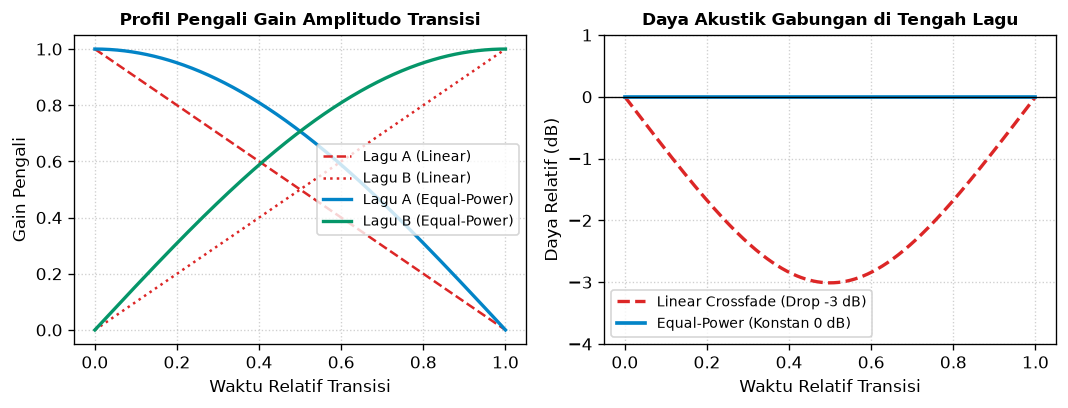

In [11]:
t_trans = np.linspace(0, 1, 500)

# Gain curves
g_lin1, g_lin2 = 1 - t_trans, t_trans
power_lin_db = 10 * np.log10(g_lin1**2 + g_lin2**2)

g_eq1, g_eq2 = np.cos(np.pi / 2 * t_trans), np.sin(np.pi / 2 * t_trans)
power_eq_db = 10 * np.log10(g_eq1**2 + g_eq2**2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))

ax1.plot(t_trans, g_lin1, color=C_ALERT, ls='--', label='Lagu A (Linear)')
ax1.plot(t_trans, g_lin2, color=C_ALERT, ls=':', label='Lagu B (Linear)')
ax1.plot(t_trans, g_eq1, color=C_SIGNAL, lw=2, label='Lagu A (Equal-Power)')
ax1.plot(t_trans, g_eq2, color=C_GOOD, lw=2, label='Lagu B (Equal-Power)')
ax1.set_title("Profil Pengali Gain Amplitudo Transisi", fontweight='bold', fontsize=10)
ax1.set_xlabel("Waktu Relatif Transisi")
ax1.set_ylabel("Gain Pengali")
ax1.grid(True, ls=':', alpha=0.6)
ax1.legend(loc='center right', fontsize=8.5)

ax2.plot(t_trans, power_lin_db, color=C_ALERT, ls='--', lw=2, label='Linear Crossfade (Drop -3 dB)')
ax2.plot(t_trans, power_eq_db, color=C_SIGNAL, lw=2.2, label='Equal-Power (Konstan 0 dB)')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_title("Daya Akustik Gabungan di Tengah Lagu", fontweight='bold', fontsize=10)
ax2.set_xlabel("Waktu Relatif Transisi")
ax2.set_ylabel("Daya Relatif (dB)")
ax2.set_ylim(-4.0, 1.0)
ax2.grid(True, ls=':', alpha=0.6)
ax2.legend(loc='lower left', fontsize=8.5)

plt.tight_layout()
plt.show()

## 9. Rangkuman & Pedoman Praktis

### 📌 Ringkasan Konsep Inti Modul 04:
1. **Sample Peak (dBFS)** hanya membaca amplitudo titik sampel diskrit; **True Peak (dBTP)** memperhitungkan gelombang analog kontinu melalui $4\times$ oversampling untuk mencegah distorsi inter-sample pada DAC pengguna.
2. **RMS** mengukur energi kontinu, sedangkan **Crest Factor ($C = \text{Peak}/\text{RMS}$)** mengukur derajat transien audio.
3. **Standar LUFS (ITU-R BS.1770)** adalah acuan global modern yang meniru respon biologis telinga manusia menggunakan filter **K-Weighting** dan sistem **Gating**.
4. **Peak Normalization** gagal menyeragamkan kenyaringan antar genre musik; industri multimedia beralih ke **Loudness Normalization** (Spotify −14 LUFS, Apple −16 LUFS, EBU R128 −23 LUFS).
5. Mendongkrak audio dinamis secara naif ke target LUFS dapat memicu **clipping ($>0\text{ dBFS}$)**. Oleh karena itu, kita membutuhkan **Dynamic Range Processing** (Compressor & Limiter) yang akan kita bedah di **Modul 05**!
6. Pada transisi antarlagu, selalu gunakan **Equal-Power Crossfade** berbasis fungsi trigonometri $(\cos/\sin)$ agar daya akustik tidak anjlok $-3\text{ dB}$ di tengah sambungan.

---
*Selamat! Anda telah menyelesaikan Modul 04. Lanjutkan ke **Modul 05: Dynamic Processing** untuk memanipulasi rentang dinamika sinyal dengan kompresor dan limiter!*